# DWT Feature Extraction 파이프라인 시각화

이 노트북은 `extract_dwt.py`에 구현된 파이프라인의 핵심 진행 단계와 각 단계의 데이터를 시각적으로 직관적으로 이해하기 위해 작성되었습니다.

**전체 파이프라인 진행 및 시각화 단계:**
1. **진폭 단계**: NPZ 파일 데이터 로드 → `CSI` 복소수에서 **Amplitude(진폭)** 만 추출
2. **PCA 압축**: 108개의 서브캐리어 차원을 시계열 특성이 통합된 상위 K개의 PC로 축소
3. **DWT + Soft Thresholding**: 최상주파수 대역의 계수 기반 노이즈 추정(MAD)과 연산 필터링으로 시계열 잡음 제거 검증
4. **Energy Extraction**: 재구성된 깨끗한 파형들의 저주파/고주파 성분 에너지 분포도 추출 및 1D-벡터화

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pywt
from sklearn.decomposition import PCA

# 전역 폰트 및 시각화 기본 설정 (Windows 한글 호환)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

## Step 1: 데이터 로드 및 진폭(Amplitude) 추출 [N x 108]
Sanitization이 완료된 데이터를 가져오고 복소 성분에서 진폭만 추출하여 데이터 형태와 특징을 시각화합니다.

분석 데이터 파일: csi_260429_232913_jinyoung_w00_big.npz
추출된 진폭(Amplitude) 형태: (253, 243)


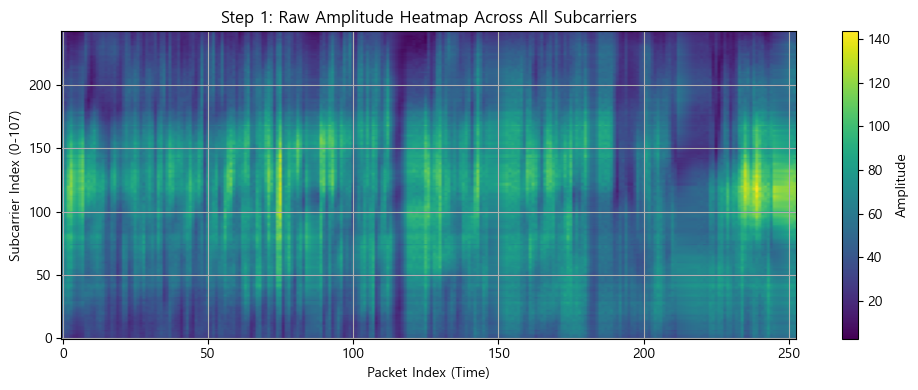

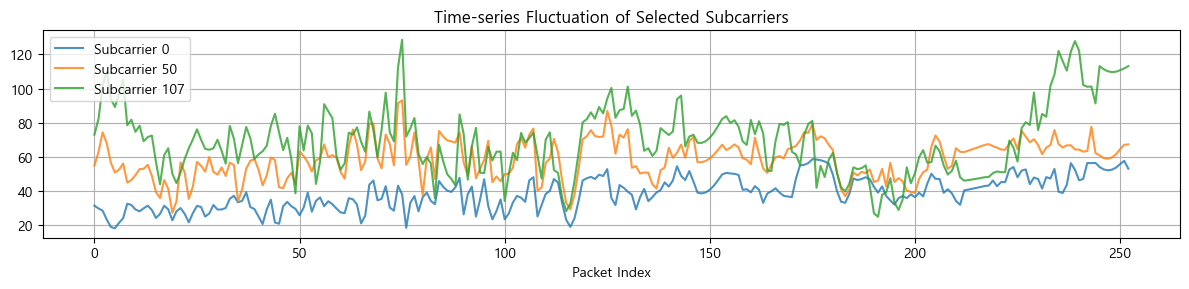

In [6]:
# 상대경로 기준 data/sanitization 경로 찾기
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
SANIT_ROOT = os.path.join(BASE_DIR, 'data', 'sanitization', 'sanitization')

# 가장 최근 날짜 폴더 탐색
sub_dirs = sorted([d for d in glob.glob(os.path.join(SANIT_ROOT, "*")) if os.path.isdir(d)])
SANIT_DIR = sub_dirs[-1] if sub_dirs else os.path.join(SANIT_ROOT, "260430")

npz_files = sorted(glob.glob(os.path.join(SANIT_DIR, '*.npz')))

if not npz_files:
    print(f'오류: {SANIT_DIR} 경로에서 파일을 찾지 못했습니다.')
else:
    sample_file = npz_files[0]
    print(f'분석 데이터 파일: {os.path.basename(sample_file)}')

    data = np.load(sample_file)
    csi_complex = data['csi']  # 복소수 [N_packets, 108]
    
    # 1. 진폭 추출
    amplitude = np.abs(csi_complex).astype(np.float32)
    print(f'추출된 진폭(Amplitude) 형태: {amplitude.shape}')

    # 2. 전체 데이터 열지도(Heatmap)
    plt.figure(figsize=(10, 4))
    plt.imshow(amplitude.T, aspect='auto', cmap='viridis', origin='lower')
    plt.colorbar(label='Amplitude')
    plt.title('Step 1: Raw Amplitude Heatmap Across All Subcarriers')
    plt.xlabel('Packet Index (Time)')
    plt.ylabel('Subcarrier Index (0-107)')
    plt.tight_layout()
    plt.show()
    
    # 3. 시간에 따른 채널 신호 변화 추이
    plt.figure(figsize=(12, 3))
    plt.plot(amplitude[:, 0], label='Subcarrier 0', alpha=0.8)
    plt.plot(amplitude[:, 50], label='Subcarrier 50', alpha=0.8)
    plt.plot(amplitude[:, 107], label='Subcarrier 107', alpha=0.8)
    plt.title('Time-series Fluctuation of Selected Subcarriers')
    plt.xlabel('Packet Index')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Step 2: PCA 서브캐리어 축 차원 축소 [N x K]
정보가 밀집된 대표 주성분(Principal Components)들을 추출하여 연산을 가볍게 만들고 정보력을 응축합니다.

PCA 압축 후 형태: (253, 6)
각 주성분이 갖는 데이터 분산 설명률: [0.58504426 0.14828983 0.12409762 0.04993987 0.03691616 0.01604015]


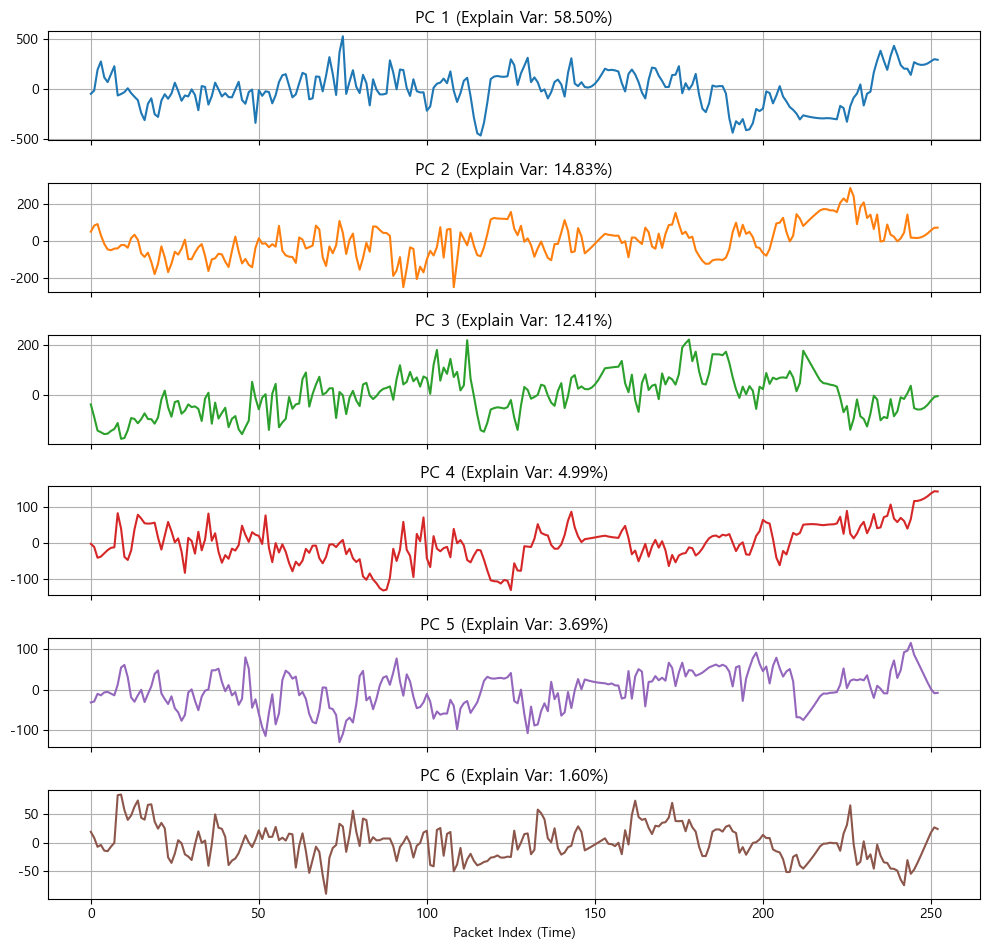

In [7]:
n_components = 6

# PCA 축소 (패킷수가 혹시 설정보다 적을 때의 예외 처리)
pca = PCA(n_components=min(n_components, amplitude.shape[0]))
pca_streams = pca.fit_transform(amplitude)

print(f'PCA 압축 후 형태: {pca_streams.shape}')
print(f'각 주성분이 갖는 데이터 분산 설명률: {pca.explained_variance_ratio_}')

# 변환된 각 주성분들을 다중 Plot
fig, axes = plt.subplots(n_components, 1, figsize=(10, 1.6 * n_components), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(pca_streams[:, i], color=f'C{i}')
    ax.set_title(f'PC {i+1} (Explain Var: {pca.explained_variance_ratio_[i]:.2%})')

axes[-1].set_xlabel('Packet Index (Time)')
plt.tight_layout()
plt.show()

## Step 3: DWT 및 Soft Thresholding (노이즈 제거)
1D 주성분 신호 속에 있는 고주파 잡음을 추출하고 `Soft Thresholding(MAD)` 방법으로 효과적으로 소멸시킵니다.
아래는 **첫 번째 PC (가장 정보를 많이 담고 있는 주성분)** 에 대한 효과 시각화입니다.

산출된 노이즈 Threshold Limits 값: 177.2410


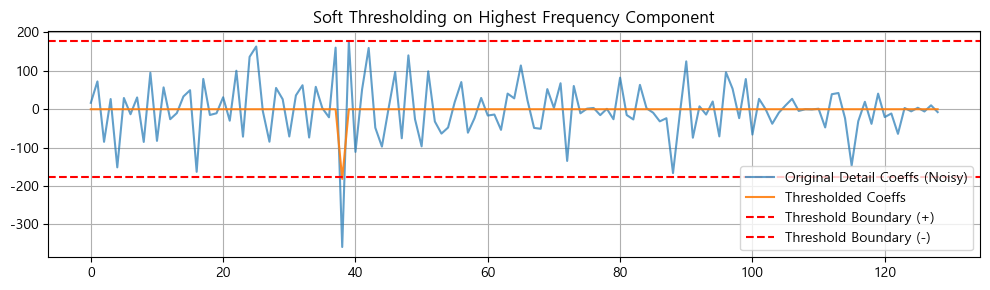

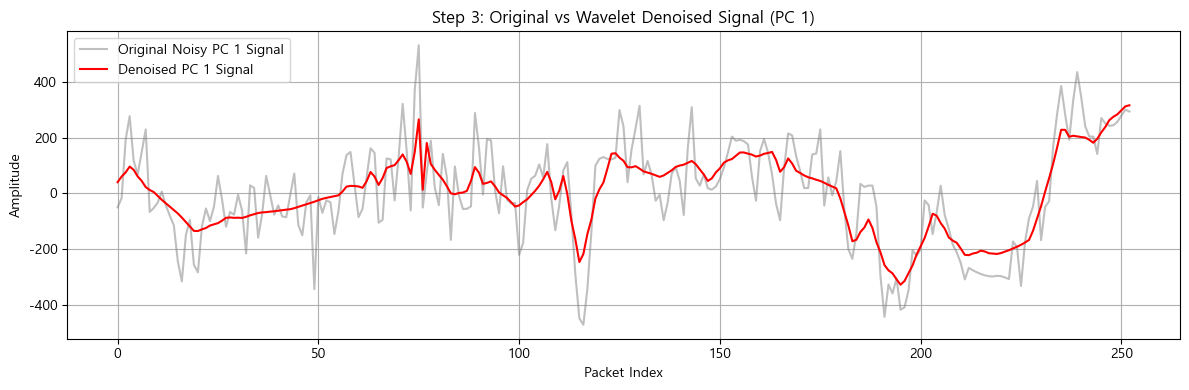

In [8]:
def soft_threshold(coeffs, threshold):
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - threshold, 0.0)

wavelet = 'sym3'
level = 10

# 분석용 1-D 시계열 선택 (PC 1)
signal_1d = pca_streams[:, 0].astype(np.float64)
actual_level = min(level, pywt.dwt_max_level(len(signal_1d), wavelet))

# [1] 웨이블릿 분해(Decomposition)
coeffs = pywt.wavedec(signal_1d, wavelet, level=actual_level)

# [2] Threshold 추정 (MAD 기준 고주파수 영역 계수들의 중앙값 기반)
highest_detail = coeffs[-1] 
sigma = np.median(np.abs(highest_detail)) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(signal_1d)))
print(f"산출된 노이즈 Threshold Limits 값: {threshold:.4f}")

# [3] 고역대 성분들(coeffs[1:])에게 Soft Thresholding 적용하여 노이즈 영역 0으로 감쇠
thresholded_coeffs = [coeffs[0]] + [soft_threshold(c, threshold) for c in coeffs[1:]]

# [4] 재구성(Reconstruction)
denoised_signal = pywt.waverec(thresholded_coeffs, wavelet)[:len(signal_1d)]

# ----------------- 시각화: Threshold 적용 전후 계수의 변화 시각화 -----------------
plt.figure(figsize=(10, 3))
plt.plot(highest_detail, label='Original Detail Coeffs (Noisy)', alpha=0.7)
plt.plot(thresholded_coeffs[-1], label='Thresholded Coeffs', alpha=0.9)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold Boundary (+)')
plt.axhline(-threshold, color='red', linestyle='--', label='Threshold Boundary (-)')
plt.title('Soft Thresholding on Highest Frequency Component')
plt.legend()
plt.tight_layout()
plt.show()

# ----------------- 시각화: 실 노이즈 캔슬링 파형 결과 변화 검증 -----------------
plt.figure(figsize=(12, 4))
plt.plot(signal_1d, color='gray', alpha=0.5, label='Original Noisy PC 1 Signal')
plt.plot(denoised_signal, color='red', linewidth=1.5, label='Denoised PC 1 Signal')
plt.title('Step 3: Original vs Wavelet Denoised Signal (PC 1)')
plt.xlabel('Packet Index')
plt.ylabel('Amplitude')
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: 구조적인 DWT Energy 성분 특징(Feature) 벡터 추출
노이즈가 사라진 신호를 다시 $Level L$ 만큼 주파스 대역별로 분해하고,
각 대역이 가진 **파워(제곱의 합산)**를 L2-정규화된 비율로 추출하여 행동을 묘사하는 핵심 Feature 로 만점니다.

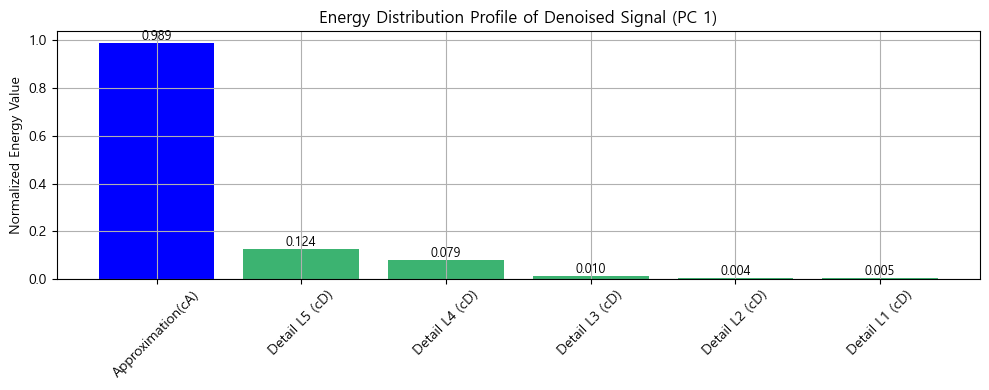

In [9]:
# 재합성된 노이즈 제거 신호 기반 DWT 재분해
final_coeffs = pywt.wavedec(denoised_signal, wavelet, level=actual_level)

# Energy Vector 산출: 대역별 신호들의 L2 Norm 크기
energy_vec = np.array([np.sum(c ** 2) for c in final_coeffs], dtype=np.float32)

norm = np.linalg.norm(energy_vec)
if norm > 1e-10:
    energy_vec = energy_vec / norm

# ----------------- 시각화: Level에 따른 정규화 Energy 성분 -----------------
labels = ['Approximation(cA)'] + [f'Detail L{actual_level - i + 1} (cD)' for i in range(1, actual_level + 1)]

plt.figure(figsize=(10, 4))
bars = plt.bar(labels, energy_vec, color=['blue'] + ['mediumseagreen'] * actual_level)
plt.title('Energy Distribution Profile of Denoised Signal (PC 1)')
plt.ylabel('Normalized Energy Value')
plt.xticks(rotation=45)

# 수치 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', va='bottom', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 5: 파이프라인 마무리 - 전체 주성분 데이터 결합 및 최종 특징 행렬
위 처리를 모든 상위 K개의 PC들에 대해 일괄 적용한 뒤,
나온 전체 에너지 벡터를 일렬로 합결(`np.concatenate`)하여 최종 기계학습 모델용 `(K x (L+1), )` 평지 벡터로 생성합니다.

최종 특징 1D 벡터 구성 Shape : (36,) = (PCA 축 6개 * 대역 6개)


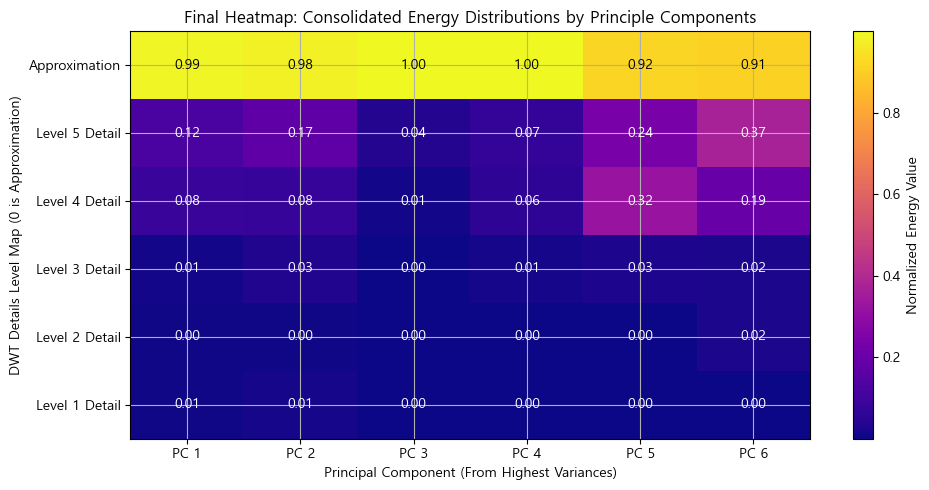

In [10]:
energy_matrix = np.zeros((n_components, actual_level + 1))
flattened_features = []

for k in range(n_components):
    sig = pca_streams[:, k].astype(np.float64)
    
    # 1. Denoising
    c_dec = pywt.wavedec(sig, wavelet, level=actual_level)
    thr = (np.median(np.abs(c_dec[-1])) / 0.6745) * np.sqrt(2 * np.log(len(sig)))
    c_thr = [c_dec[0]] + [soft_threshold(c, thr) for c in c_dec[1:]]
    denoised = pywt.waverec(c_thr, wavelet)[:len(sig)]
    
    # 2. Extract Energy Vector feature
    c_final = pywt.wavedec(denoised, wavelet, level=actual_level)
    e_vec = np.array([np.sum(x**2) for x in c_final], dtype=np.float32)
    norm_val = np.linalg.norm(e_vec)
    if norm_val > 1e-10:
        e_vec = e_vec / norm_val
        
    flattened_features.append(e_vec)
    energy_matrix[k, :] = e_vec

# 병합
final_1d_feature = np.concatenate(flattened_features)
print(f'최종 특징 1D 벡터 구성 Shape : {final_1d_feature.shape} = (PCA 축 {n_components}개 * 대역 {actual_level + 1}개)')

# ----------------- 시각화: 모든 주성분의 에너지 분포 히트맵 -----------------
plt.figure(figsize=(10, 5))
plt.imshow(energy_matrix.T, aspect='auto', cmap='plasma')

# 데이터 값 텍스트 입히기
for (j, i), val in np.ndenumerate(energy_matrix.T):
    plt.text(i, j, f'{val:.2f}', ha='center', va='center', color='white' if val < 0.6 else 'black')

plt.colorbar(label='Normalized Energy Value')
plt.title('Final Heatmap: Consolidated Energy Distributions by Principle Components')
plt.xlabel('Principal Component (From Highest Variances)')
plt.ylabel('DWT Details Level Map (0 is Approximation)')

yticks_labels = ['Approximation'] + [f'Level {actual_level - i + 1} Detail' for i in range(1, actual_level + 1)]
plt.yticks(ticks=np.arange(actual_level + 1), labels=yticks_labels)
plt.xticks(ticks=range(n_components), labels=[f'PC {i+1}' for i in range(n_components)])
plt.tight_layout()
plt.show()